# BTC Volatility — Halving Cycle Analysis

**Source:** `analytics.btc_price_features`  
**Thesis:** Bitcoin realized volatility has declined structurally with each halving cycle.

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import text

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / '.env')
from etl.common.db.postgres import get_engine

engine = get_engine()

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'font.size':        9,
})

In [2]:
with engine.connect() as conn:
    feat = pd.read_sql(
        text("""
            SELECT f.date_day,
                   f.realized_vol_7d,
                   f.realized_vol_14d,
                   f.realized_vol_30d,
                   f.realized_vol_90d,
                   f.vol_ratio_7_30,
                   f.halving_number,
                   f.days_since_halving,
                   m.btc_close_usd
            FROM analytics.btc_price_features f
            LEFT JOIN analytics.btc_market_daily m USING (date_day)
            WHERE f.realized_vol_30d IS NOT NULL
            ORDER BY f.date_day
        """),
        conn,
    )

feat['date_day'] = pd.to_datetime(feat['date_day'])
feat = feat.set_index('date_day')

# Convert to percentage for display
for col in ['realized_vol_7d', 'realized_vol_14d', 'realized_vol_30d', 'realized_vol_90d']:
    feat[col] = feat[col] * 100

# Halving dates for vertical lines
HALVINGS = {
    1: ('2012-11-28', 'Halving #1'),
    2: ('2016-07-09', 'Halving #2'),
    3: ('2020-05-11', 'Halving #3'),
    4: ('2024-04-20', 'Halving #4'),
}

print(f"Data: {feat.index.min().date()} → {feat.index.max().date()}  ({len(feat):,} rows)")
print()
print(feat.groupby('halving_number')['realized_vol_30d'].agg(['min','max','mean']).round(1).rename(
    columns={'min': 'vol_30d_min %', 'max': 'vol_30d_max %', 'mean': 'vol_30d_avg %'}
))

Data: 2010-08-17 → 2026-04-27  (5,731 rows)

                vol_30d_min %  vol_30d_max %  vol_30d_avg %
halving_number                                             
0                        14.3          305.5          120.3
1                        14.6          366.3           75.7
2                        15.8          163.8           73.0
3                        15.7          113.7           58.0
4                        22.5           82.4           44.2


## Chart 1 — Full History: 30d Realized Vol (annualized %)

Log scale — required to show the full arc from 300%+ early BTC to sub-50% today.

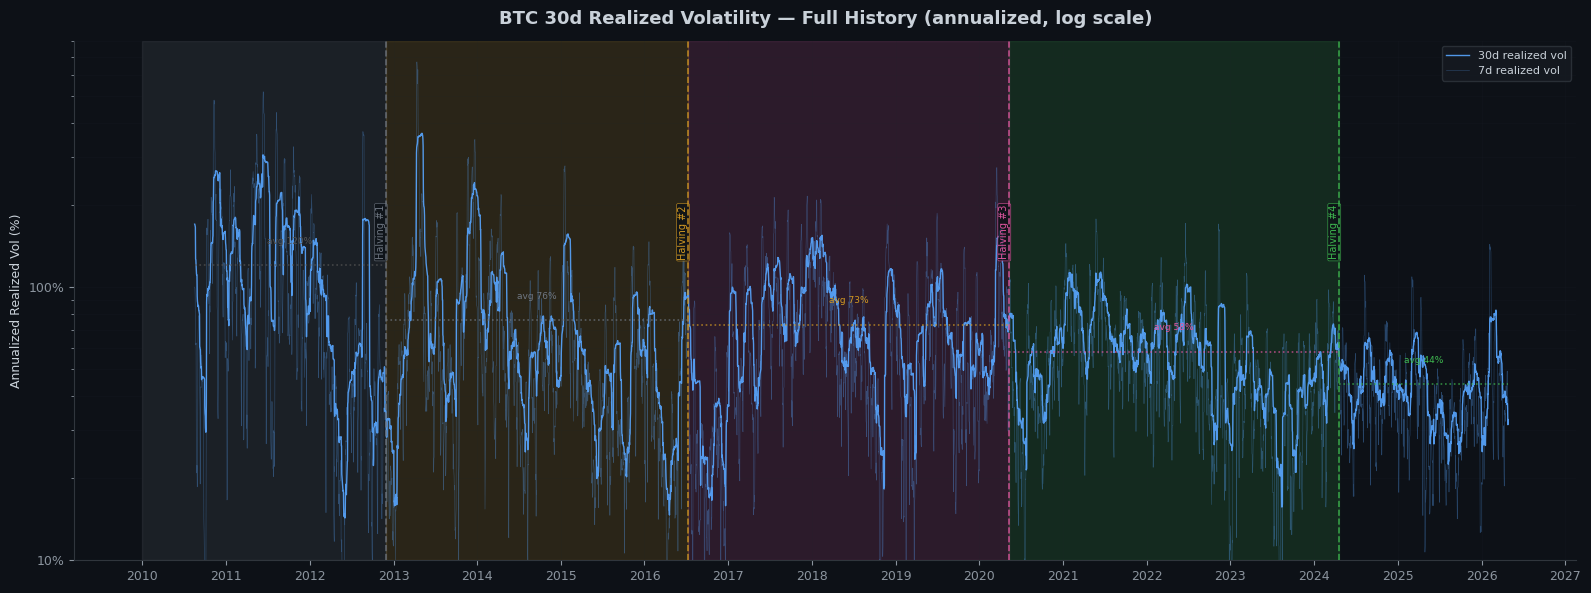

In [3]:
# Shade each halving cycle a slightly different background tone
CYCLE_SHADES = {
    1: '#161b22', 2: '#0d1117', 3: '#161b22', 4: '#0d1117'
}
CYCLE_COLORS = {
    1: '#6e7681', 2: '#d29922', 3: '#E056A0', 4: '#3FB950'
}

fig, ax = plt.subplots(figsize=(16, 6))

# Shade cycle bands
boundaries = [pd.Timestamp('2010-01-01')] + \
             [pd.Timestamp(d) for d, _ in HALVINGS.values()] + \
             [feat.index.max() + pd.Timedelta(days=1)]

for i, (h_num, (h_date, _)) in enumerate(HALVINGS.items()):
    x0 = boundaries[i]
    x1 = boundaries[i + 1]
    ax.axvspan(x0, x1, alpha=0.15, color=CYCLE_COLORS[h_num], zorder=0)

# Vol line
ax.semilogy(feat.index, feat['realized_vol_30d'], color='#58A6FF', linewidth=1.0,
            alpha=0.9, zorder=3, label='30d realized vol')
ax.semilogy(feat.index, feat['realized_vol_7d'],  color='#58A6FF', linewidth=0.4,
            alpha=0.35, zorder=2, label='7d realized vol')

# Halving vertical lines + labels
for h_num, (h_date, h_label) in HALVINGS.items():
    dt = pd.Timestamp(h_date)
    if dt < feat.index.min():
        continue
    ax.axvline(dt, color=CYCLE_COLORS[h_num], linewidth=1.2, linestyle='--', alpha=0.8, zorder=4)
    ax.text(dt, 200, h_label, fontsize=7, color=CYCLE_COLORS[h_num],
            rotation=90, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='#0d1117', alpha=0.8,
                      edgecolor=CYCLE_COLORS[h_num], linewidth=0.5))

# Cycle average lines
for h_num, grp in feat.groupby('halving_number'):
    avg = grp['realized_vol_30d'].mean()
    x0 = grp.index.min()
    x1 = grp.index.max()
    ax.hlines(avg, x0, x1, color=CYCLE_COLORS.get(h_num, '#555'), linewidth=1.2,
              linestyle=':', alpha=0.7, zorder=5)
    ax.text(x0 + (x1 - x0) * 0.5, avg * 1.18, f'avg {avg:.0f}%',
            fontsize=6.5, color=CYCLE_COLORS.get(h_num, '#555'), ha='center', va='bottom')

ax.set_ylim(10, 800)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, which='both', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('BTC 30d Realized Volatility — Full History (annualized, log scale)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Annualized Realized Vol (%)')
ax.legend(fontsize=8, loc='upper right', facecolor='#161b22', edgecolor='#30363d')

plt.tight_layout()
plt.show()

## Chart 2 — Halving Cycle Overlay: Vol by Days Since Halving

Each line starts at day 0 (the halving date). Directly compares vol profiles across cycles.
Halving #4 line ends at the latest available data point.

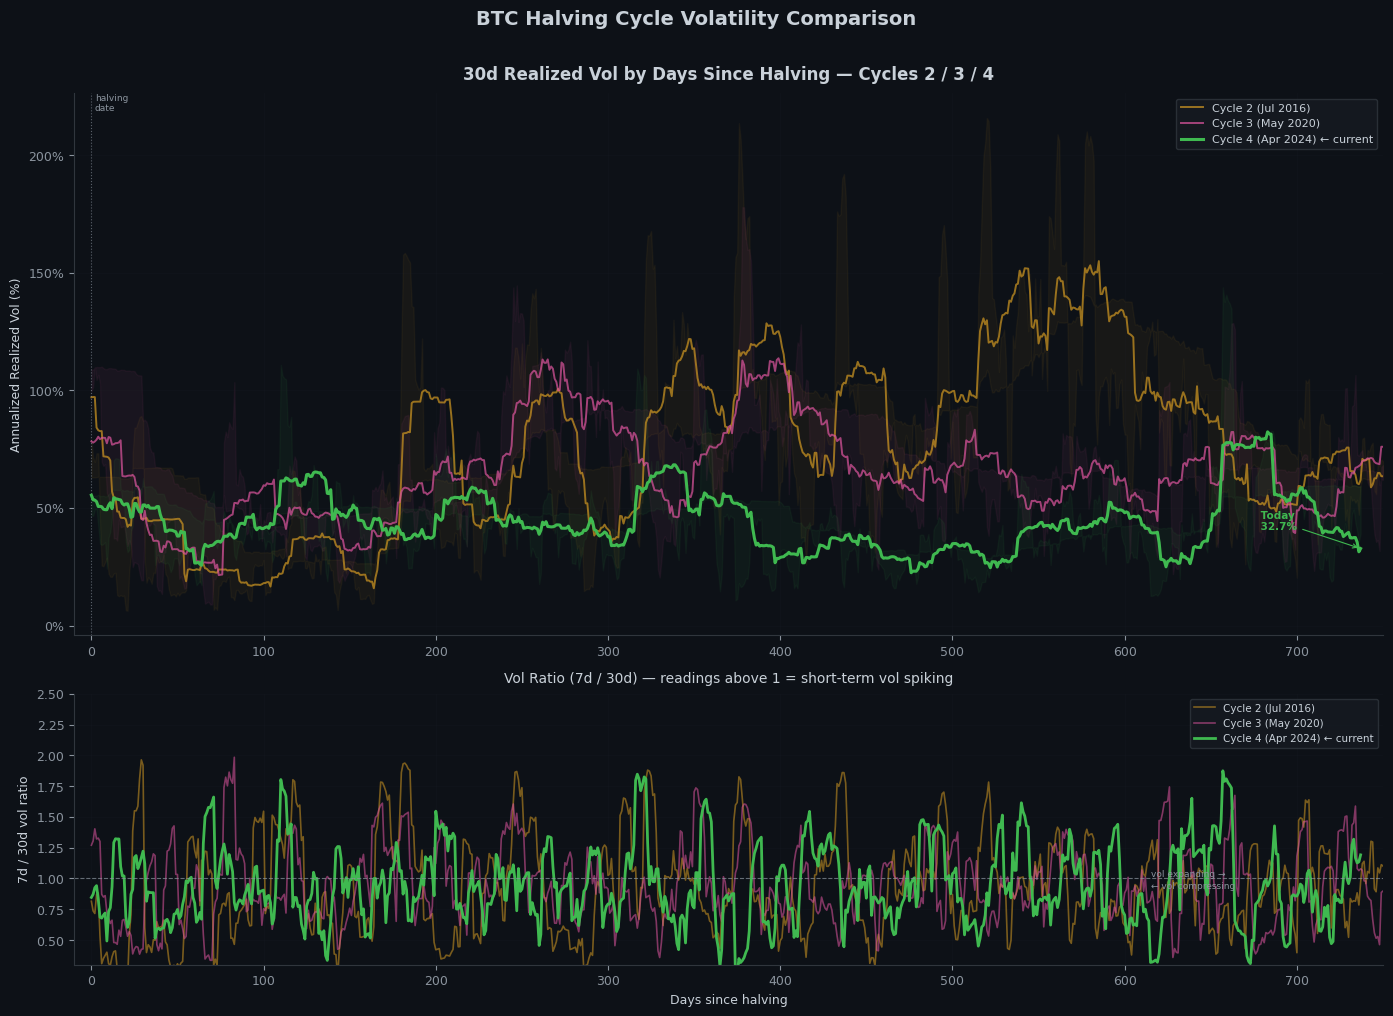

In [4]:
# Focus on cycles 2, 3, 4 — pre-2016 BTC vol is not comparable to today's market
CYCLE_WINDOW = 750  # days to show after each halving

cycle_colors = {2: '#d29922', 3: '#E056A0', 4: '#3FB950'}
cycle_labels = {2: 'Cycle 2 (Jul 2016)', 3: 'Cycle 3 (May 2020)', 4: 'Cycle 4 (Apr 2024) ← current'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})
fig.subplots_adjust(hspace=0.35)

# ── Top: 30d realized vol overlay ────────────────────────────────────────────
for h_num in [2, 3, 4]:
    cycle = feat[feat['halving_number'] == h_num].copy()
    cycle = cycle[cycle['days_since_halving'] <= CYCLE_WINDOW]
    color = cycle_colors[h_num]
    lw    = 2.2 if h_num == 4 else 1.4
    alpha = 1.0 if h_num == 4 else 0.7

    ax1.plot(cycle['days_since_halving'], cycle['realized_vol_30d'],
             color=color, linewidth=lw, alpha=alpha, label=cycle_labels[h_num], zorder=h_num)

    # Rolling 90d vol as a shaded band
    ax1.fill_between(cycle['days_since_halving'],
                     cycle['realized_vol_7d'], cycle['realized_vol_90d'],
                     color=color, alpha=0.06)

    # Annotate current position for cycle 4
    if h_num == 4:
        last = cycle.iloc[-1]
        ax1.annotate(
            f" Today\n {last['realized_vol_30d']:.1f}%",
            xy=(last['days_since_halving'], last['realized_vol_30d']),
            xytext=(last['days_since_halving'] - 60, last['realized_vol_30d'] + 8),
            fontsize=7.5, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=0.8),
        )

ax1.axvline(0, color='#8b949e', linewidth=0.8, linestyle=':', alpha=0.6)
ax1.text(2, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 1 else 100,
         'halving\ndate', fontsize=6.5, color='#8b949e', va='top')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.set_xlim(-10, CYCLE_WINDOW)
ax1.grid(True, alpha=0.2)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_title('30d Realized Vol by Days Since Halving — Cycles 2 / 3 / 4', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Annualized Realized Vol (%)')
ax1.legend(fontsize=8, loc='upper right', facecolor='#161b22', edgecolor='#30363d')

# ── Bottom: vol ratio (7d / 30d) for current cycle only ──────────────────────
for h_num in [2, 3, 4]:
    cycle = feat[feat['halving_number'] == h_num].copy()
    cycle = cycle[cycle['days_since_halving'] <= CYCLE_WINDOW]
    color = cycle_colors[h_num]
    lw    = 2.0 if h_num == 4 else 1.2
    alpha = 1.0 if h_num == 4 else 0.55

    ax2.plot(cycle['days_since_halving'], cycle['vol_ratio_7_30'],
             color=color, linewidth=lw, alpha=alpha, label=cycle_labels[h_num])

ax2.axhline(1.0, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.7)
ax2.text(CYCLE_WINDOW * 0.82, 1.02, 'vol expanding →', fontsize=6.5, color='#8b949e')
ax2.text(CYCLE_WINDOW * 0.82, 0.92, '← vol compressing', fontsize=6.5, color='#8b949e')

ax2.set_xlim(-10, CYCLE_WINDOW)
ax2.set_ylim(0.3, 2.5)
ax2.grid(True, alpha=0.2)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_title('Vol Ratio (7d / 30d) — readings above 1 = short-term vol spiking', fontsize=10, pad=8)
ax2.set_ylabel('7d / 30d vol ratio')
ax2.set_xlabel('Days since halving')
ax2.legend(fontsize=7.5, loc='upper right', facecolor='#161b22', edgecolor='#30363d')

plt.suptitle('BTC Halving Cycle Volatility Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Summary Table — Vol Statistics per Halving Cycle

In [5]:
rows = []
for h_num, grp in feat.groupby('halving_number'):
    v = grp['realized_vol_30d']
    rows.append({
        'Cycle': f'Halving #{h_num}',
        'Start date': grp.index.min().date(),
        'End date':   grp.index.max().date(),
        'Days in data': len(grp),
        'Vol min %':  round(v.min(), 1),
        'Vol avg %':  round(v.mean(), 1),
        'Vol median %': round(v.median(), 1),
        'Vol max %':  round(v.max(), 1),
        'Days above 100%': int((v > 100).sum()),
        'Days above 50%':  int((v > 50).sum()),
        'Days below 40%':  int((v < 40).sum()),
    })

summary = pd.DataFrame(rows).set_index('Cycle')
summary

,Start date,End date,Days in data,Vol min %,Vol avg %,Vol median %,Vol max %,Days above 100%,Days above 50%,Days below 40%
Cycle,,,,,,,,,,
Halving #0,2010-08-17,2012-11-27,834,14.3,120.3,104.9,305.5,440,655,105
Halving #1,2012-11-28,2016-07-08,1319,14.6,75.7,60.3,366.3,247,819,308
Halving #2,2016-07-09,2020-05-10,1400,15.8,73.0,68.0,163.8,270,1021,195
Halving #3,2020-05-11,2024-04-19,1440,15.7,58.0,56.9,113.7,59,863,283
Halving #4,2024-04-20,2026-04-27,738,22.5,44.2,41.7,82.4,0,206,293


## Chart 3 — Percentile Distribution: How "Quiet" Is Cycle 4 Relative to History?

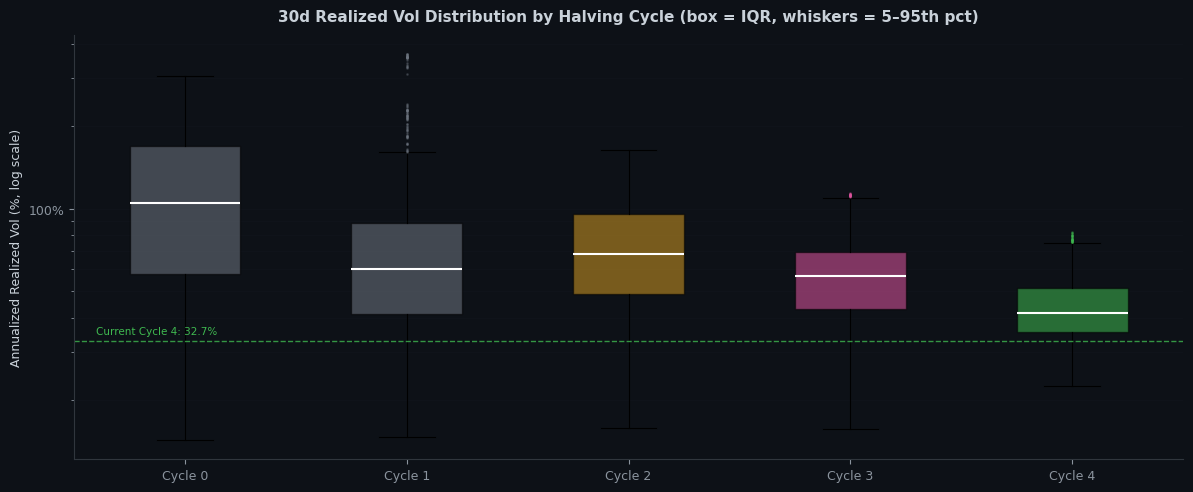

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

# For each cycle, show a box plot of 30d vol distribution
data_by_cycle = [
    feat[feat['halving_number'] == h]['realized_vol_30d'].dropna().values
    for h in sorted(feat['halving_number'].unique())
]
labels = [f'Cycle {int(h)}' for h in sorted(feat['halving_number'].unique())]
colors_box = ['#6e7681', '#6e7681', '#d29922', '#E056A0', '#3FB950']

bp = ax.boxplot(data_by_cycle, labels=labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=1.5),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for flier, color in zip(bp['fliers'], colors_box):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Annotate cycle 4 current reading
current_vol = feat[feat['halving_number'] == 4]['realized_vol_30d'].iloc[-1]
ax.axhline(current_vol, color='#3FB950', linewidth=1.0, linestyle='--', alpha=0.8)
ax.text(0.6, current_vol + 2, f'Current Cycle 4: {current_vol:.1f}%',
        fontsize=7.5, color='#3FB950')

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(True, which='both', alpha=0.2, axis='y')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('30d Realized Vol Distribution by Halving Cycle (box = IQR, whiskers = 5–95th pct)', 
             fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Annualized Realized Vol (%, log scale)')

plt.tight_layout()
plt.show()